In [24]:
import os
path = r"C:\Users\lokesh\AllFiles\UCSD\Deep-Generative-Models\wiki-art"
print("Contents:", os.listdir(path))
print(path)

Contents: ['images']
C:\Users\lokesh\AllFiles\UCSD\Deep-Generative-Models\wiki-art


In [25]:
import torch

# make sure gpu is available
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU


In [26]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from pytorch_msssim import ssim

import numpy as np

transform = transforms.Compose([
    transforms.Resize((64, 64)),  # img dimensions, reshape to 64 x 64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
])

dataset = ImageFolder(path, transform=transform)

train_size = int(len(dataset) * 0.8)

train_dataset, test_dataset = random_split(dataset, [train_size, len(dataset) - train_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}") 

Batch shape: torch.Size([64, 3, 64, 64])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Generator(nn.Module):
    def __init__(self): 
        super(Generator, self).__init__()

        # Generator
        self.generator = nn.Sequential(

            # 1 -> 4
            nn.ConvTranspose2d(100, 512, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            
            # 4 -> 8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            # 8 -> 16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            # 16 -> 32
            nn.ConvTranspose2d(128, 64,kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 32 -> 64
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.generator(noise)

class Discriminator(nn.Module):
    def __init__(self): 
        super(Discriminator, self).__init__()

        # Adversery
        self.discriminator = nn.Sequential(

            # 64 -> 32
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(),

            # 32 -> 16
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            
            # 16 -> 8
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(),
            
            # 8 -> 4
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(),

            # 4 -> 1
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )
    
    def forward(self, img):
        return self.discriminator(img)


In [ ]:
# initialize model
model_gen = Generator().to(device)
model_dis = Discriminator().to(device)

optimizer_gen = torch.optim.Adam(model_gen.parameters(), lr= 0.0002, betas=(0.5, 0.999))
optimizer_dis = torch.optim.Adam(model_dis.parameters(), lr= 0.0002, betas=(0.5, 0.999))

bce_loss = nn.BCELoss()

In [29]:
# initialize weights as normal distributions to avoid very random initializations (very extreme values)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02) # mean 0, std 0.02
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02) # mean 1, std 0.02
        nn.init.constant_(m.bias.data, 0)

In [30]:
model_dis.apply(weights_init)

Discriminator(
  (discriminator): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
    (12): Sigmoid()
  )
)

In [31]:
model_gen.apply(weights_init)

Generator(
  (generator): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): Tanh()
  )
)

In [32]:
def loss_dis(real, fake):
    batch_size = real.size(0)
    # get predictions
    real_pred = model_dis(real).view(-1, 1)
    
    fake_pred = model_dis(fake).view(-1, 1)

    # create the lables, 1 for real, 2 for fake
    true_label = torch.ones(batch_size, 1, device=device)
    false_label = torch.zeros(batch_size, 1, device=device)

    # compute both losses
    real_loss = bce_loss(real_pred, true_label)
    fake_loss = bce_loss(fake_pred, false_label)

    return (real_loss + fake_loss) / 2

def loss_gen(fake):
    batch_size = fake.size(0)
    # we try to cheat discriminator so we need 1
    target_label = torch.ones(batch_size, 1, device=device)
    fake_pred = model_dis(fake).view(-1, 1)

    loss = bce_loss(fake_pred, target_label)

    return loss

In [33]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

Epoch 0, Generator Loss: 13.890068151406012, Discriminator Loss: 752.4950716421008
Epoch 1, Generator Loss: 13.829268676228821, Discriminator Loss: 331.8048049211502
Epoch 2, Generator Loss: 18.282211031764746, Discriminator Loss: 329.7138550952077
Epoch 3, Generator Loss: 10.503604295663536, Discriminator Loss: 295.3997949361801
Epoch 4, Generator Loss: 13.156338587403297, Discriminator Loss: 287.6349320411682
Epoch 5, Generator Loss: 17.718455374240875, Discriminator Loss: 299.6308639496565
Epoch 6, Generator Loss: 15.312989138066769, Discriminator Loss: 249.49224823713303
Epoch 7, Generator Loss: 19.321050902828574, Discriminator Loss: 309.55994391441345
Epoch 8, Generator Loss: 21.101886939257383, Discriminator Loss: 267.71395844221115
Epoch 9, Generator Loss: 22.932046994566917, Discriminator Loss: 251.99471592903137
Epoch 10, Generator Loss: 19.925591964274645, Discriminator Loss: 248.49676603078842
Epoch 11, Generator Loss: 15.141894664615393, Discriminator Loss: 266.89557075500

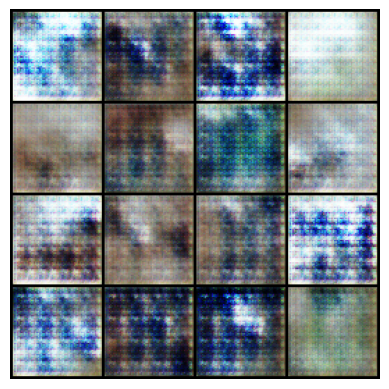

Epoch 20, Generator Loss: 16.769341617822647, Discriminator Loss: 252.5395409464836
Epoch 21, Generator Loss: 15.616440910845995, Discriminator Loss: 240.70986926555634
Epoch 22, Generator Loss: 20.086258940398693, Discriminator Loss: 243.20652782917023
Epoch 23, Generator Loss: 19.64831229299307, Discriminator Loss: 224.9814499616623
Epoch 24, Generator Loss: 20.93223036825657, Discriminator Loss: 224.9615907073021
Epoch 25, Generator Loss: 18.09888930618763, Discriminator Loss: 231.58293265104294
Epoch 26, Generator Loss: 18.534014688804746, Discriminator Loss: 237.66827917099
Epoch 27, Generator Loss: 18.25816258788109, Discriminator Loss: 231.77065241336823
Epoch 28, Generator Loss: 18.11836800724268, Discriminator Loss: 243.6507597565651
Epoch 29, Generator Loss: 17.66324921324849, Discriminator Loss: 240.13289415836334
Epoch 30, Generator Loss: 15.99230232834816, Discriminator Loss: 249.3088464140892
Epoch 31, Generator Loss: 16.929209038615227, Discriminator Loss: 246.1229887008

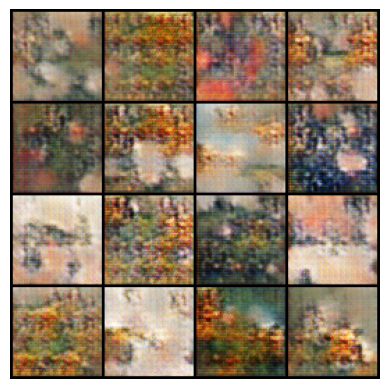

Epoch 40, Generator Loss: 17.597224351018667, Discriminator Loss: 251.55333584547043
Epoch 41, Generator Loss: 16.245537852868438, Discriminator Loss: 259.57236737012863
Epoch 42, Generator Loss: 18.600142672657967, Discriminator Loss: 249.34279423952103
Epoch 43, Generator Loss: 18.231635384261608, Discriminator Loss: 233.08026546239853
Epoch 44, Generator Loss: 20.546677973121405, Discriminator Loss: 229.33152145147324
Epoch 45, Generator Loss: 20.687680646777153, Discriminator Loss: 243.08080995082855
Epoch 46, Generator Loss: 16.256211519241333, Discriminator Loss: 221.01748025417328
Epoch 47, Generator Loss: 16.82004952430725, Discriminator Loss: 252.14705449342728
Epoch 48, Generator Loss: 16.0724547021091, Discriminator Loss: 248.09974010288715
Epoch 49, Generator Loss: 15.195623438805342, Discriminator Loss: 251.54160964488983
Epoch 50, Generator Loss: 15.723287649452686, Discriminator Loss: 253.20394533872604
Epoch 51, Generator Loss: 15.828117951750755, Discriminator Loss: 25

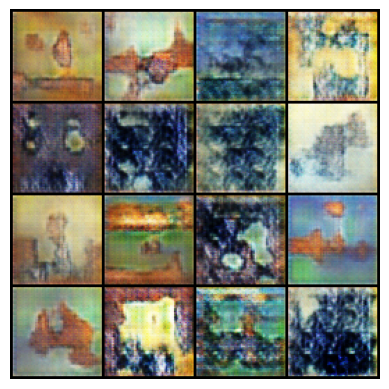

Epoch 60, Generator Loss: 12.813997462391853, Discriminator Loss: 284.0505517721176
Epoch 61, Generator Loss: 11.140258863568306, Discriminator Loss: 262.66131472587585
Epoch 62, Generator Loss: 14.094389915466309, Discriminator Loss: 280.25080478191376
Epoch 63, Generator Loss: 10.316049192100763, Discriminator Loss: 267.3851374387741
Epoch 64, Generator Loss: 11.361572567373514, Discriminator Loss: 277.93629562854767
Epoch 65, Generator Loss: 12.07589703798294, Discriminator Loss: 278.021376311779
Epoch 66, Generator Loss: 12.919680837541819, Discriminator Loss: 283.12134474515915
Epoch 67, Generator Loss: 12.830754585564137, Discriminator Loss: 277.09172570705414
Epoch 68, Generator Loss: 12.42675307765603, Discriminator Loss: 273.41976404190063
Epoch 69, Generator Loss: 9.90860215574503, Discriminator Loss: 282.67124223709106
Epoch 70, Generator Loss: 9.65344838052988, Discriminator Loss: 297.8795094490051
Epoch 71, Generator Loss: 10.287825329229236, Discriminator Loss: 303.386174

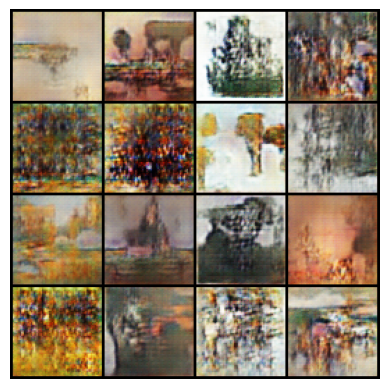

Epoch 80, Generator Loss: 10.249099891632795, Discriminator Loss: 302.85945773124695
Epoch 81, Generator Loss: 7.943384945392609, Discriminator Loss: 308.5740554332733
Epoch 82, Generator Loss: 9.92220820300281, Discriminator Loss: 324.6907341480255
Epoch 83, Generator Loss: 7.925915107131004, Discriminator Loss: 302.9818904399872
Epoch 84, Generator Loss: 9.29719877615571, Discriminator Loss: 318.64969277381897
Epoch 85, Generator Loss: 7.300192430615425, Discriminator Loss: 323.2119879722595
Epoch 86, Generator Loss: 12.496000934392214, Discriminator Loss: 337.66168665885925
Epoch 87, Generator Loss: 9.472289051860571, Discriminator Loss: 305.699369430542
Epoch 88, Generator Loss: 6.799227822571993, Discriminator Loss: 325.7931023836136
Epoch 89, Generator Loss: 6.3068545162677765, Discriminator Loss: 322.7685043811798
Epoch 90, Generator Loss: 7.735639598220587, Discriminator Loss: 339.23469042778015
Epoch 91, Generator Loss: 7.050969861447811, Discriminator Loss: 343.48830020427704

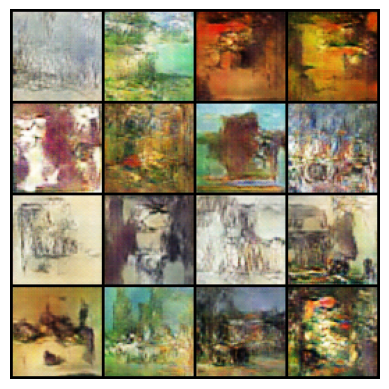

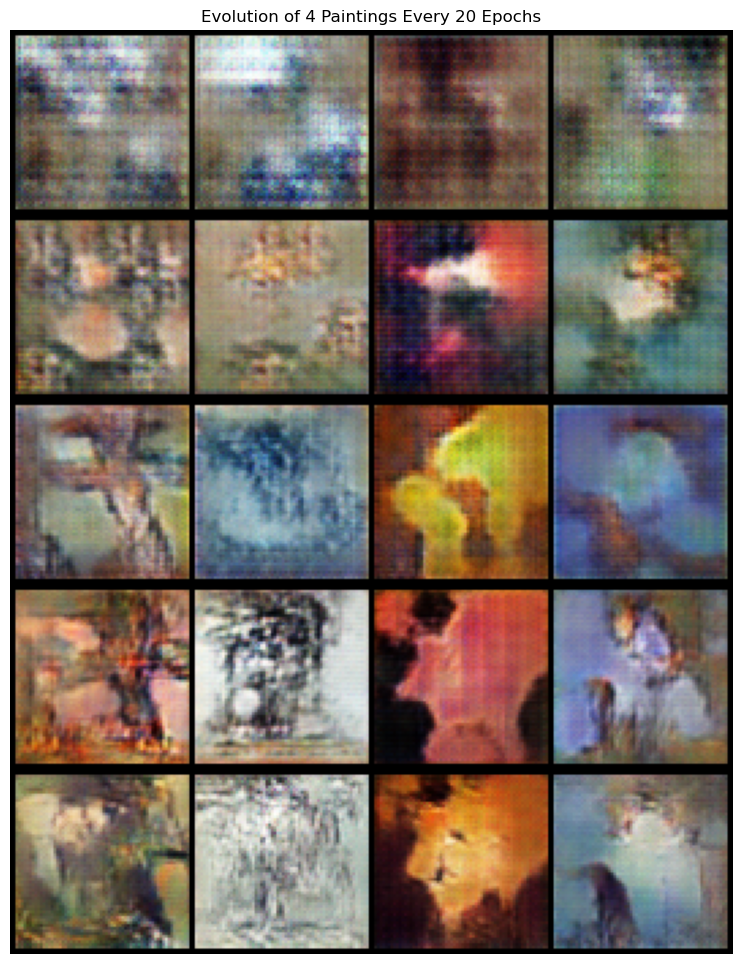

In [34]:
# for seeing how the model gets good over more epochs
comparison_strips = []
fixed_noise = torch.randn(4, 100, 1, 1, device=device)

model_gen.train()
model_dis.train()
epoch = 100
dis_loss_history = []
gen_loss_history = []

# training loop
for e in range(epoch):
    # keep track of loss for plotting
    # this is the total loss
    g_loss = d_loss = 0
    # loop through each batch
    for _, (image, labels) in enumerate(train_loader):
        real = image.to(device)
        batch_size = real.size(0)
        random_100x1x1 = torch.randn(batch_size, 100, 1, 1, device= device)

        # generator part
        optimizer_gen.zero_grad()
        fake = model_gen(random_100x1x1)
        gen_batch_loss = loss_gen(fake)
        g_loss += gen_batch_loss.item()
        gen_batch_loss.backward()
        optimizer_gen.step()

        # discriminator part
        optimizer_dis.zero_grad()
        fake = fake.detach()
        dis_batch_loss = loss_dis(real, fake)
        d_loss += dis_batch_loss.item()
        dis_batch_loss.backward()
        optimizer_dis.step()

    # saves loss curve
    dis_loss_history.append(d_loss)
    gen_loss_history.append(g_loss)
    print(f'Epoch {e}, Generator Loss: {d_loss}, Discriminator Loss: {g_loss}')

    if (e + 1) % 20 == 0:  
        # save model every 20 epochs
        torch.save(model_gen.state_dict(), f'gen_{e+1}.pth')
        torch.save(model_dis.state_dict(), f'dis_{e+1}.pth')
        print(f"-> Models saved at epoch {e+1}")

        # display some generations to verify progress
        model_gen.eval()
        with torch.no_grad():
            # just to visually check if generator is learning
            noise = torch.randn(16, 100, 1, 1, device=device)
            fake_display = model_gen(noise).detach().cpu()

            # we will use the same noise vector to generate and save the results
            # this way, we can see how the model evolves over epochs for the same input
            evolve_fakes = model_gen(fixed_noise).detach().cpu()
            current_strip = vutils.make_grid(evolve_fakes, nrow=4, normalize=True)
            comparison_strips.append(current_strip)

        grid = vutils.make_grid(fake_display, nrow=4, normalize=True)
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.axis('off')
        plt.show()
        model_gen.train() # set back to train

# saving the evolution
all_stages = torch.cat(comparison_strips, dim=1) # stack vertically
plt.figure(figsize=(10, 12))
plt.imshow(np.transpose(all_stages, (1, 2, 0)))
plt.title("Evolution of 4 Paintings Every 20 Epochs")
plt.axis('off')
plt.savefig("evolution_strip.png")
plt.show()